# XGBoost Periyar - Combined

In [2]:
! pip install mlxtend

In [3]:
import shap
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load and balance dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'DistToRoad', 'DistToStre', 'Elevation1',
       'FlowDir1', 'LULC1', 'NDBI1', 'NDVI1', 'NDWI1', 'PlanarCurv',
       'Rainfall1', 'Rainfall2', 'Rainfall3', 'Rainfall4', 'Rainfall5',
       'Rainfall6', 'Rainfall7', 'Rainfall8', 'Rainfall9', 'Rainfall10',
       'Rainfall11', 'Slope1', 'SPI1', 'STI1', 'TPI1', 'TRI1', 'TWI1', 'WRI1',
       'Target_Var'],
      dtype='object')


In [5]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 6432
Total Columns: 30

First 5 Rows:
                                            wkt_geom   Aspect1  DistToRoad  \
0  PointZ (660808.91387751756701618 1125912.32571...  0.452086   30.002138   
1  PointZ (655919.37658706970978528 1137256.37391...       NaN   42.430210   
2  PointZ (661792.93298613862134516 1138300.14105...       NaN  180.013779   
3  PointZ (646884.05534000787883997 1138047.13062...       NaN   67.090622   
4  PointZ (653209.34352380444761366 1139662.58189...       NaN   84.861305   

   DistToStre  Elevation1  FlowDir1  LULC1     NDBI1     NDVI1     NDWI1  ...  \
0  212.132034    0.083799  0.450980     10  0.445073  0.667561  0.271971  ...   
1  276.586334    0.064516  0.988858     10       NaN       NaN       NaN  ...   
2  150.000000    0.084375  0.587744     50       NaN       NaN       NaN  ...   
3   84.852814    0.266667  0.806723     10       NaN       NaN       NaN  ...   
4  228.473190    0.034562  0.376045     50       NaN       NaN       NaN  ..

In [9]:
import shap
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN  # SMOTE + Tomek Links combination
import warnings

warnings.filterwarnings("ignore")

# ==== Load and Preprocess ====
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
df = df.sample(frac=1, random_state=42).reset_index(drop=True).fillna(0)

# ==== Feature & Target ====
target_column = "Target_Var"
X = df.drop(columns=[target_column, "wkt_geom"], errors="ignore")
y = df[target_column]
classes = sorted(y.unique())

print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ==== Train-Test Split ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== Apply SMOTE + Tomek Links (SMOTE-Tomek) ====
smote_tomek = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

# ==== Scale ====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ==== Grid Search for XGBoost with expanded parameters ====
xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Expanded hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7, 10, 12],  # Depth of each tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],  # Step size in gradient descent
    'subsample': [0.7, 0.8, 0.9, 1.0],  # Fraction of samples for each tree
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Fraction of features for each tree
    'gamma': [0, 0.1, 0.2, 0.3],  # Regularization term (controls tree pruning)
    'min_child_weight': [1, 5, 10, 15],  # Minimum weight for a child node
    'scale_pos_weight': [1, 2, 5, 10]  # For handling class imbalance
}

# Apply GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(xgb_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_res)

# ==== Best Model ====
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# ==== Predict and Evaluate ====
y_pred = best_xgb.predict(X_test_scaled)
y_proba = best_xgb.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"]
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

# ==== Confusion Matrix Plot ====
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost with SMOTE-Tomek')
plt.tight_layout()
plt.show()

# ==== Feature Importance ====
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost')
plt.tight_layout()
plt.show()


Features (X) Shape: (6432, 28)
Target (y) Shape: (6432,)
Fitting 3 folds for each of 102400 candidates, totalling 307200 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize y_test for multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard (0)', 'Flood (1)', 'Landslide (2)']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# Assuming y_test, y_pred, y_proba already exist
df_xgb = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Prob_Class_0': y_proba[:, 0],
    'Prob_Class_1': y_proba[:, 1],
    'Prob_Class_2': y_proba[:, 2]
})

# Save to your desired path
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\XGBoost_Combined_Results.csv"
df_xgb.to_csv(save_path, index=False)

print(f"Saved XGBoost multi-class predictions to {save_path}")


Saved XGBoost multi-class predictions to C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\XGBoost_Combined_Results.csv


## SHAP FOR XGBoost Flood - Best Model From Comparison

In [66]:
! pip install shap imbalanced-learn pandas scikit-learn matplotlib seaborn


🔹 SHAP values for first test sample:
 Aspect1           0.042335
DistToRoads1     -0.635717
DistToStreams1    0.137647
Elevation1       -0.521495
FlowDir1         -0.047863
Geomorphology1    0.000000
LULC1            -0.119302
NDBI1            -0.173466
NDVI1             0.010585
NDWI1            -0.050446
PlanarCurv1      -0.046776
Rainfall1        -0.506927
Rainfall2        -0.338631
Rainfall3        -1.139803
Rainfall4        -0.631802
Rainfall5        -0.161953
Rainfall6        -0.161993
Rainfall7        -0.051445
Rainfall8        -0.334709
Rainfall9        -0.817032
Rainfall10       -0.219896
Rainfall11       -0.297024
Slope1            0.044851
SPI1              0.059586
TPI1              0.073245
TRI1              0.027843
WRI1             -0.019223
Name: 0, dtype: float32

📊 Global SHAP Feature Importance:
            Feature  Mean_Absolute_SHAP
11       Rainfall1            0.650843
1     DistToRoads1            0.486045
3       Elevation1            0.444175
6            LUL

<Figure size 640x480 with 0 Axes>

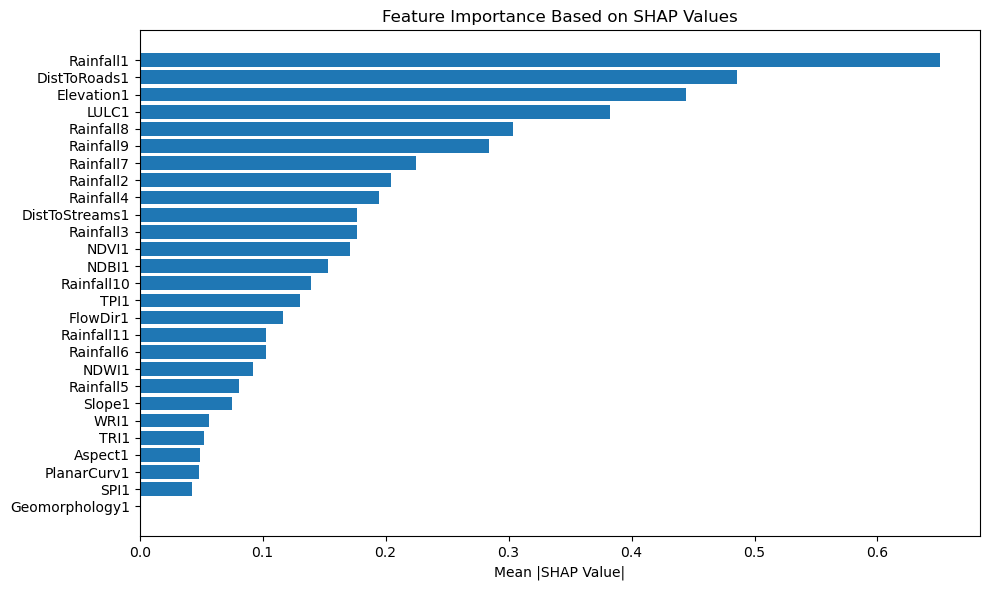

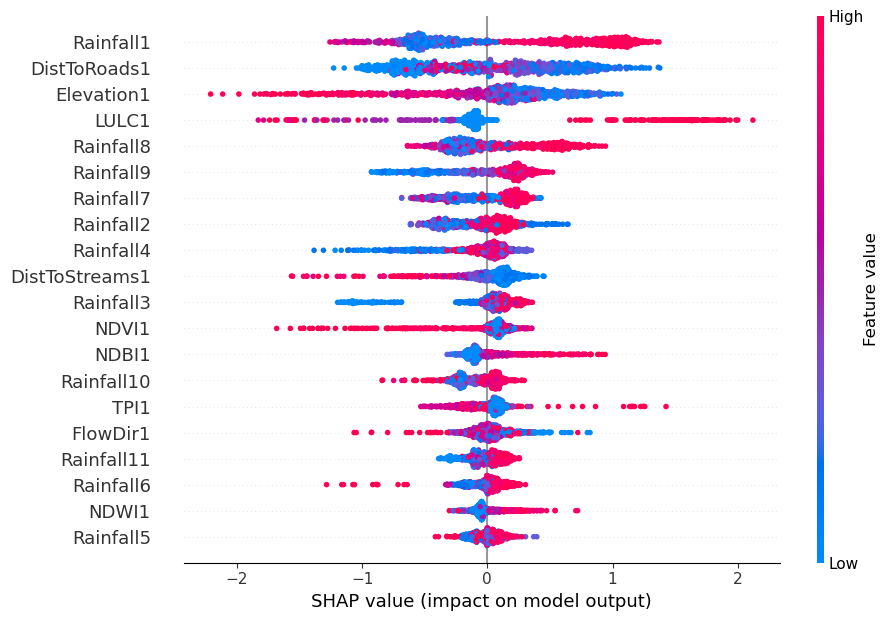

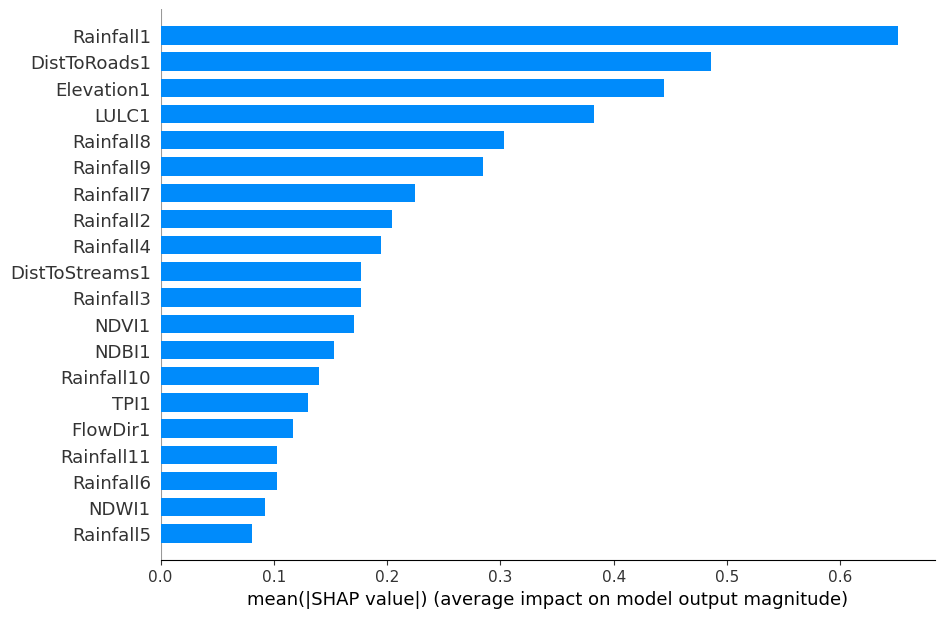

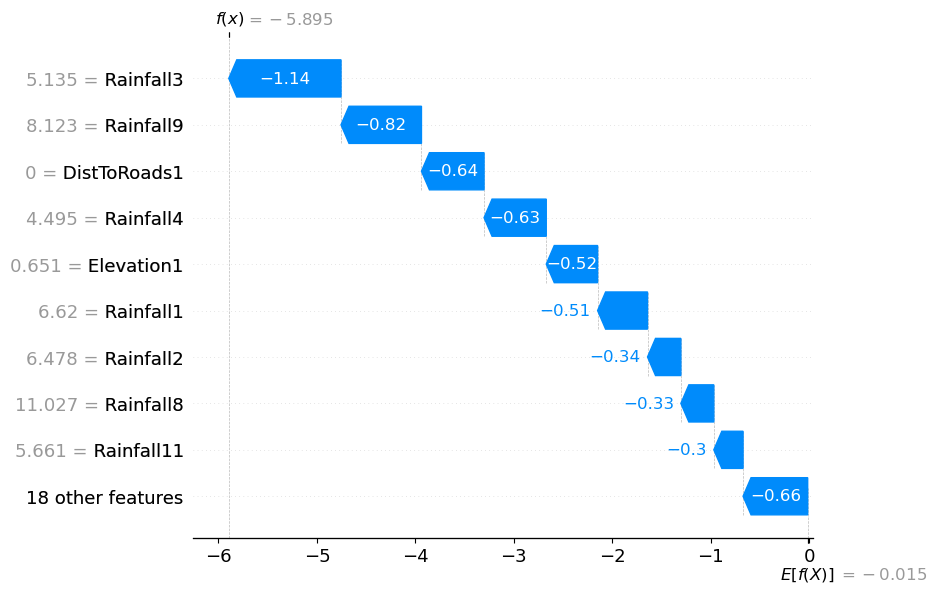

In [68]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Define output path
output_dir = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SHAP\XGBoost"
os.makedirs(output_dir, exist_ok=True)

# Create SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Save SHAP values per sample
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv(os.path.join(output_dir, "shap_values_all_samples.csv"), index=False)
print("\n🔹 SHAP values for first test sample:\n", shap_df.iloc[0])

# Global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({'Feature': X_test.columns, 'Mean_Absolute_SHAP': mean_abs_shap})
shap_importance = shap_importance.sort_values(by='Mean_Absolute_SHAP', ascending=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_global_importance.csv"), index=False)
print("\n📊 Global SHAP Feature Importance:\n", shap_importance)

# Bar plot - Mean Absolute SHAP
plt.figure(figsize=(10, 6))
plt.barh(shap_importance['Feature'], shap_importance['Mean_Absolute_SHAP'])
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance Based on SHAP Values')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "bar_plot_mean_absolute_shap.png"), dpi=300)
plt.show()

# --- Summary Plot (beeswarm) ---
shap.summary_plot(shap_values, X_test, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)  # Set a fixed size if needed
fig.savefig(os.path.join(output_dir, "summary_plot_beeswarm.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# --- Summary Plot (bar) ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(output_dir, "summary_plot_bar.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Dependence plots - Save individually
for feature in X_test.columns:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    fig = plt.gcf()
    fig.savefig(os.path.join(output_dir, f"dependence_plot_{feature}.png"), dpi=300, bbox_inches='tight')
    plt.close()

# Force Plot (interactive HTML, correct way)
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
shap.save_html(os.path.join(output_dir, "force_plot_sample_0.html"), force_plot)  # ✅ this works

# Generate waterfall plot (inline show=True is OK)
waterfall_plot = shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
), show=False)

# Save manually from the current figure
fig = plt.gcf()
fig.savefig(os.path.join(output_dir, "waterfall_plot_sample_0.png"), dpi=300, bbox_inches='tight')
plt.show()



🔹 SHAP values for sample 0:
 Aspect1           0.042335
DistToRoads1     -0.635717
DistToStreams1    0.137647
Elevation1       -0.521495
FlowDir1         -0.047863
Geomorphology1    0.000000
LULC1            -0.119302
NDBI1            -0.173466
NDVI1             0.010585
NDWI1            -0.050446
PlanarCurv1      -0.046776
Rainfall1        -0.506927
Rainfall2        -0.338631
Rainfall3        -1.139803
Rainfall4        -0.631802
Rainfall5        -0.161953
Rainfall6        -0.161993
Rainfall7        -0.051445
Rainfall8        -0.334709
Rainfall9        -0.817032
Rainfall10       -0.219896
Rainfall11       -0.297024
Slope1            0.044851
SPI1              0.059586
TPI1              0.073245
TRI1              0.027843
WRI1             -0.019223
Name: 0, dtype: float32

📊 Global SHAP importance:
            Feature  Mean_Absolute_SHAP
11       Rainfall1            0.650843
1     DistToRoads1            0.486045
3       Elevation1            0.444175
6            LULC1            0.3

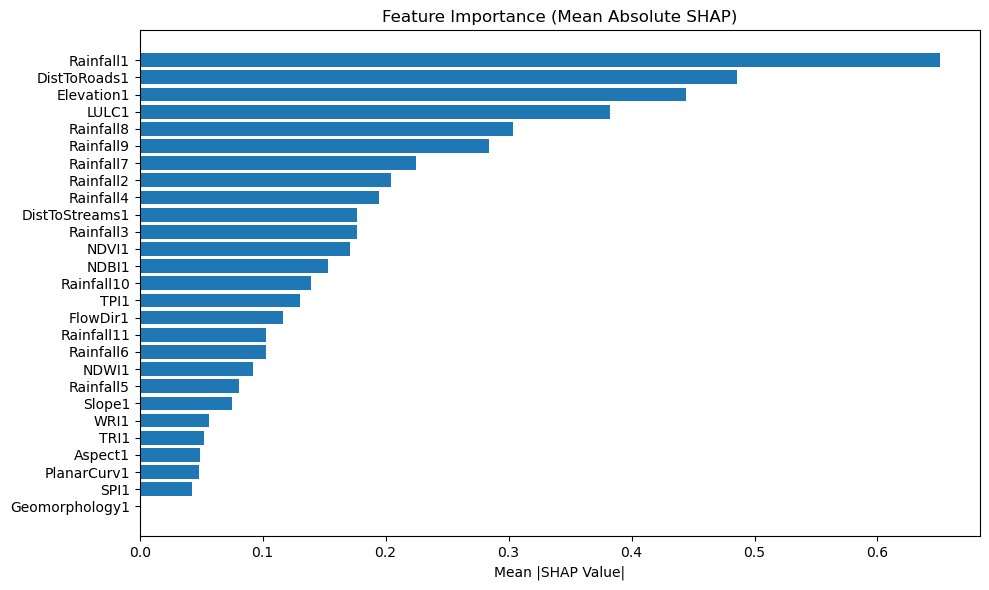

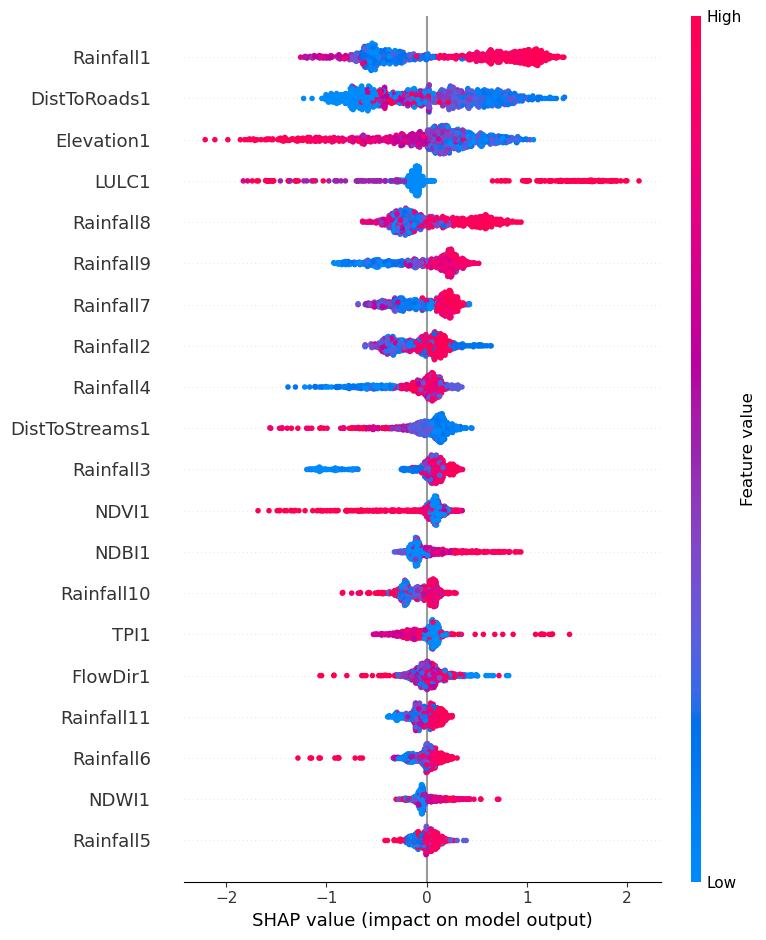

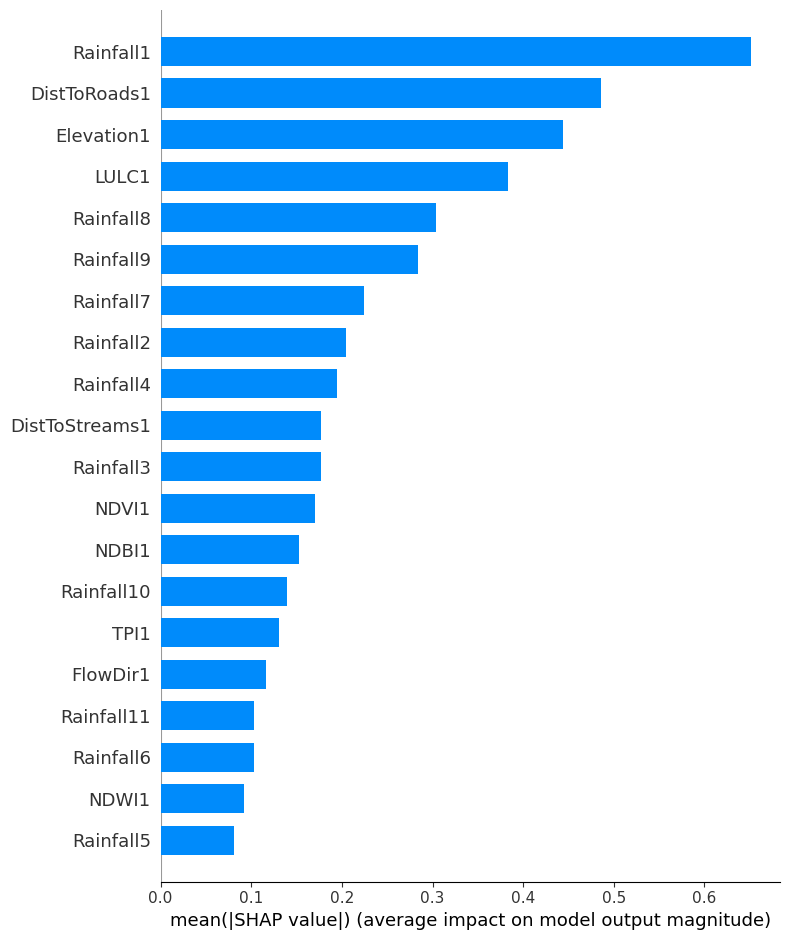

<Figure size 640x480 with 0 Axes>

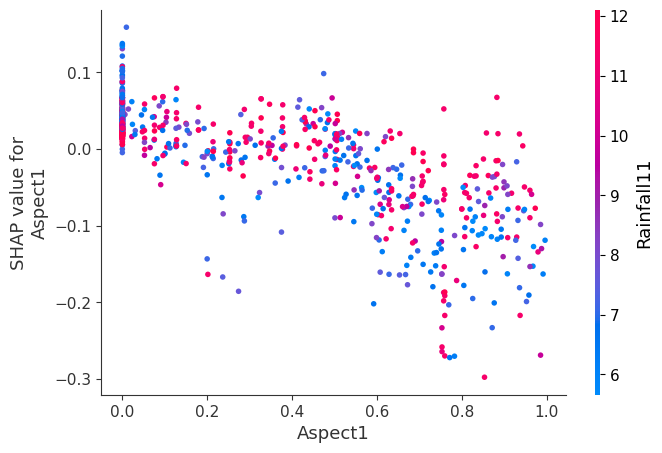

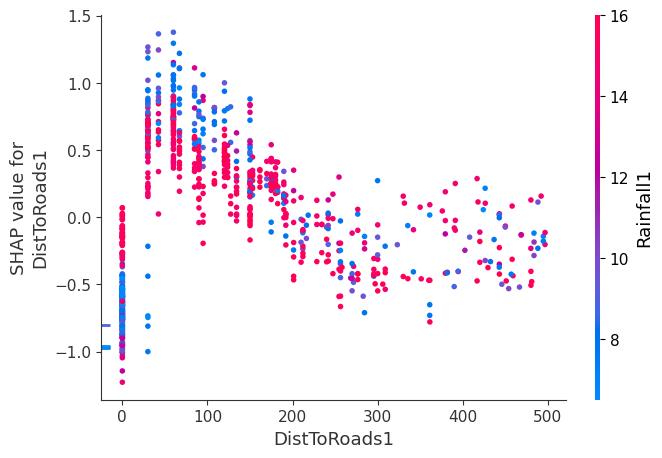

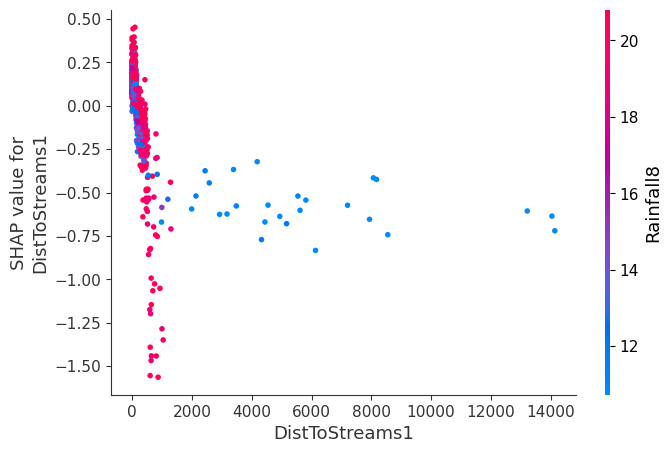

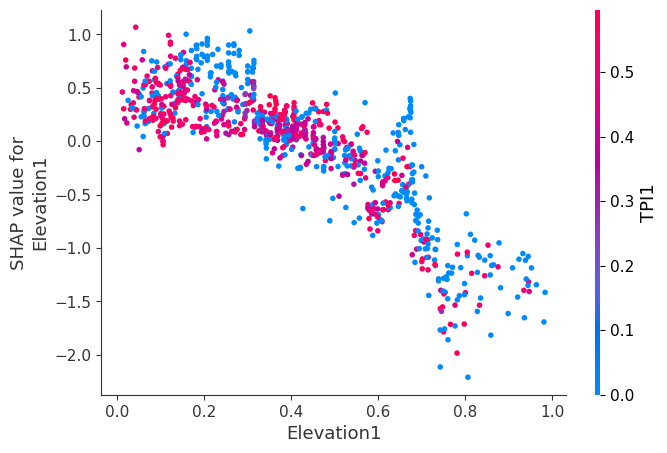

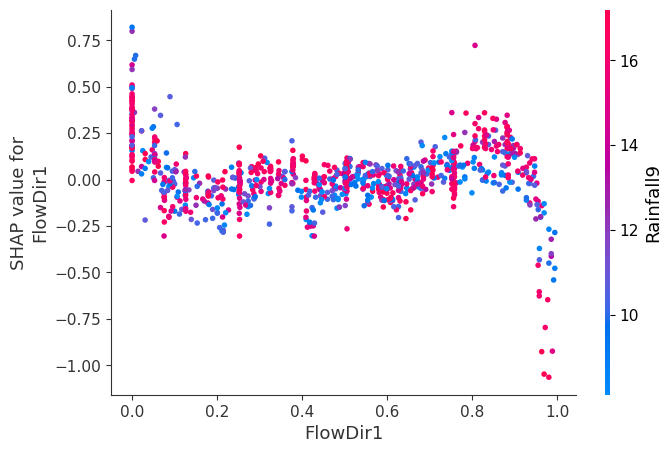

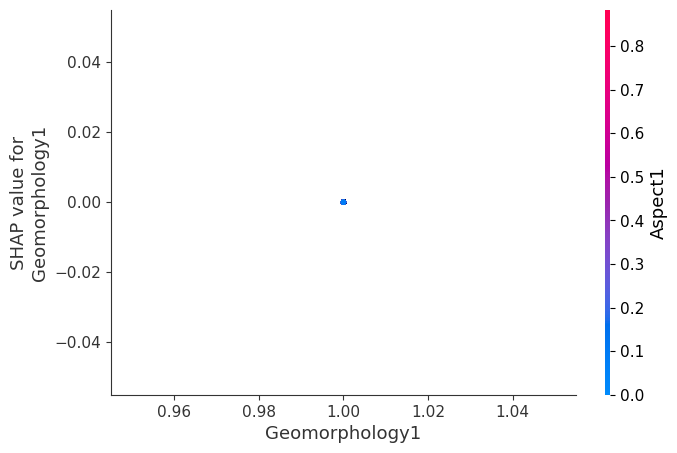

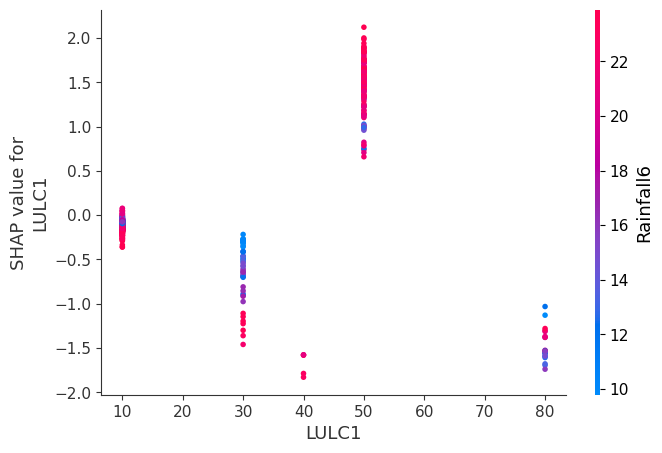

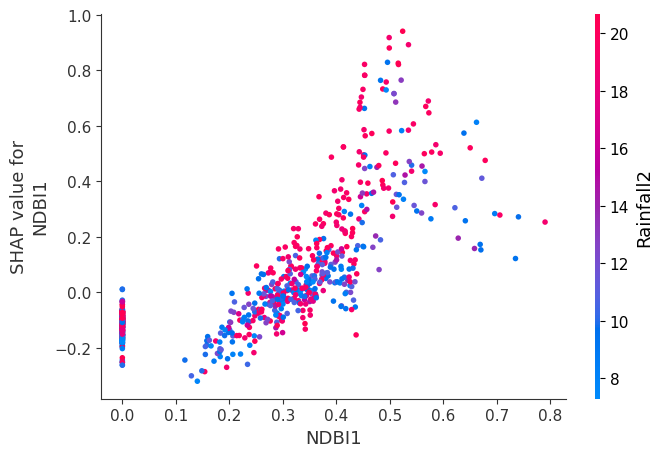

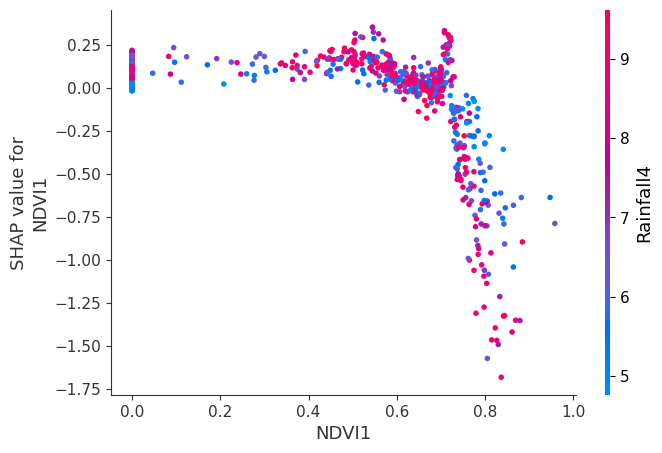

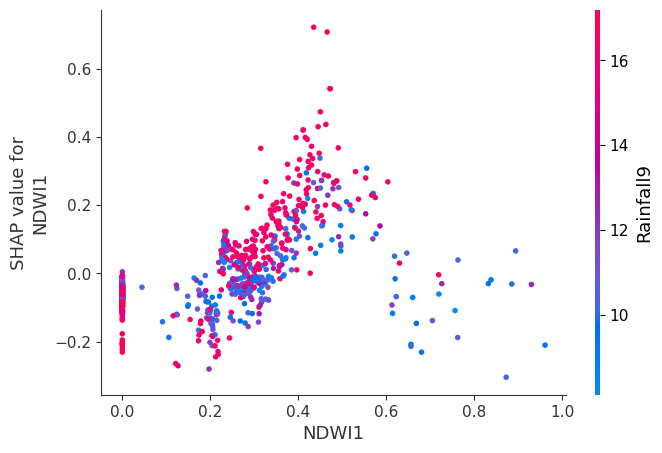

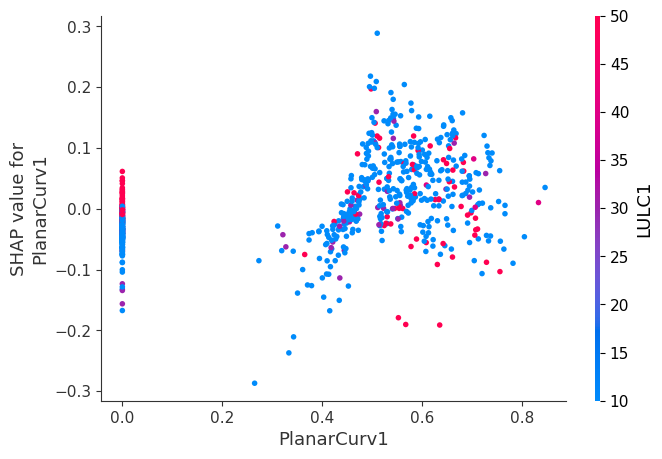

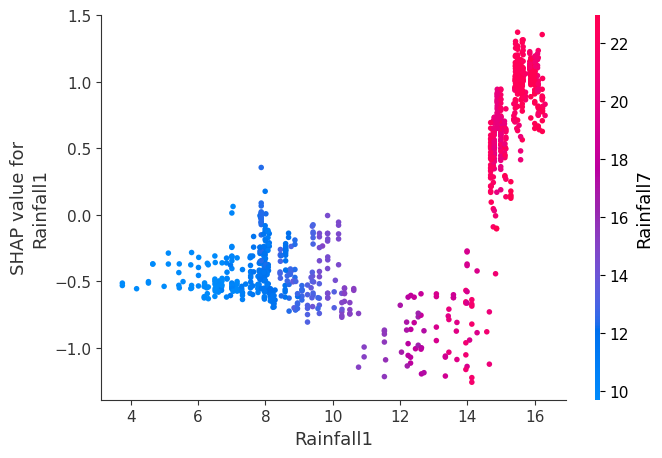

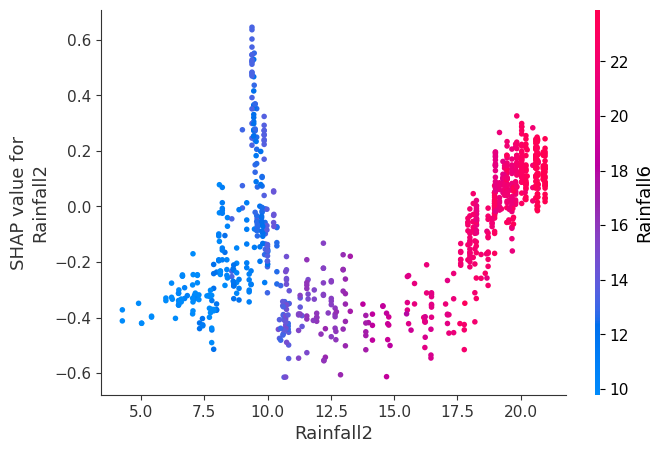

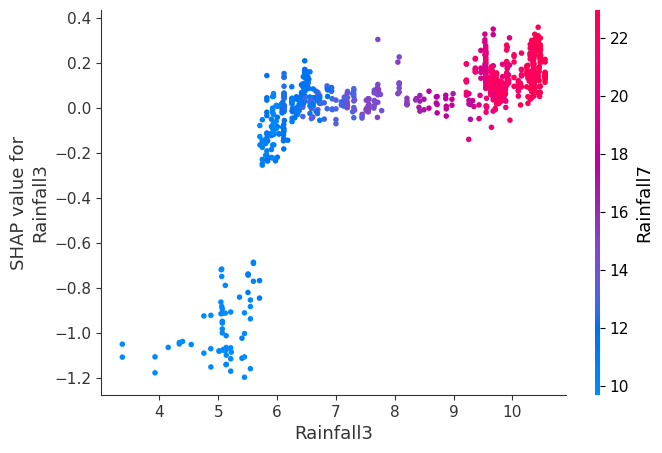

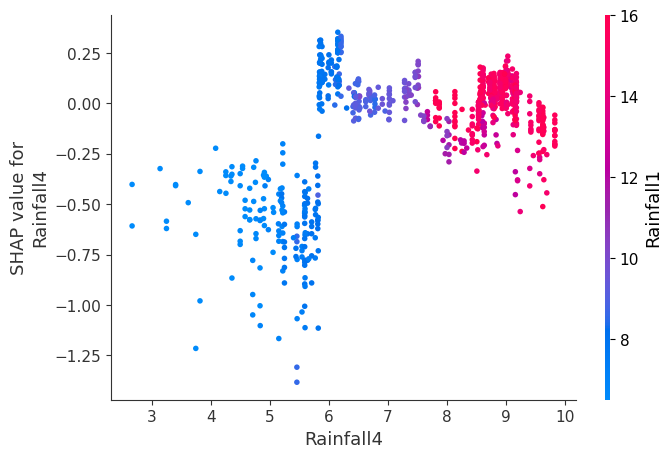

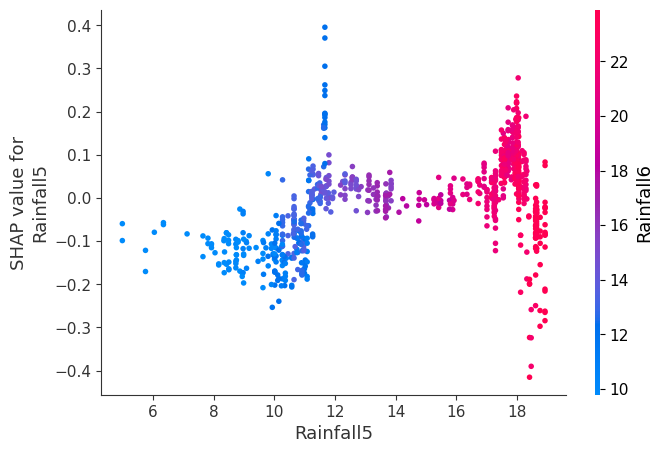

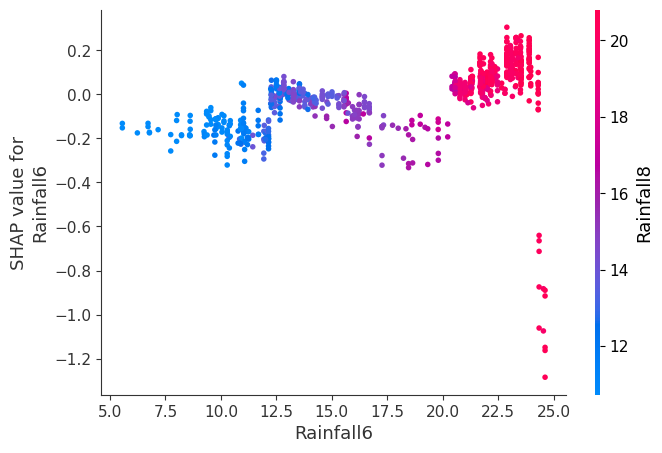

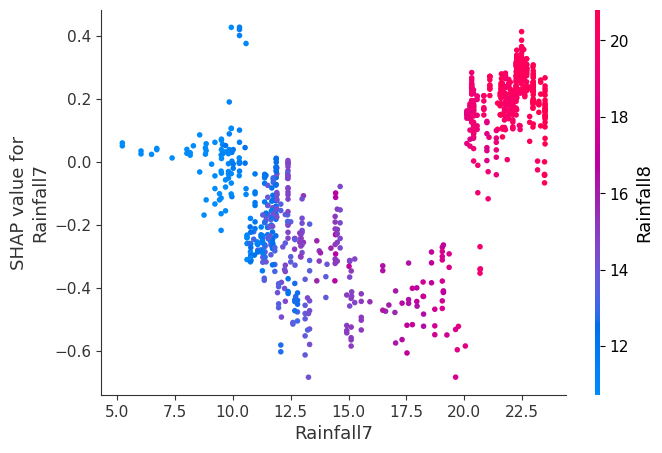

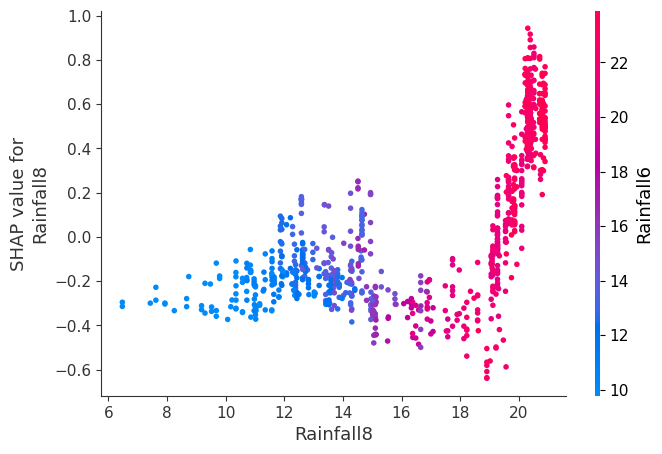

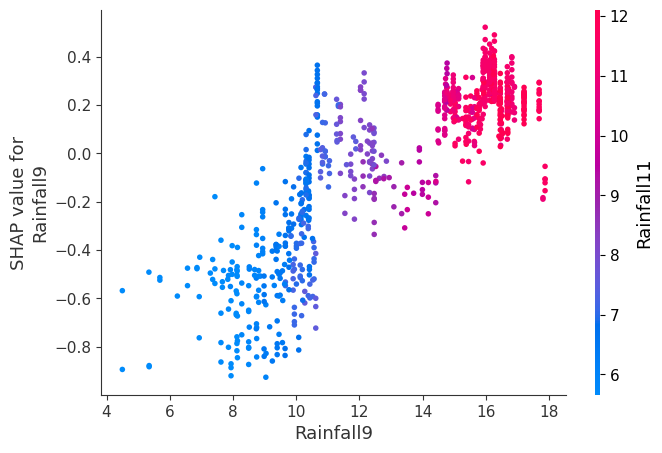

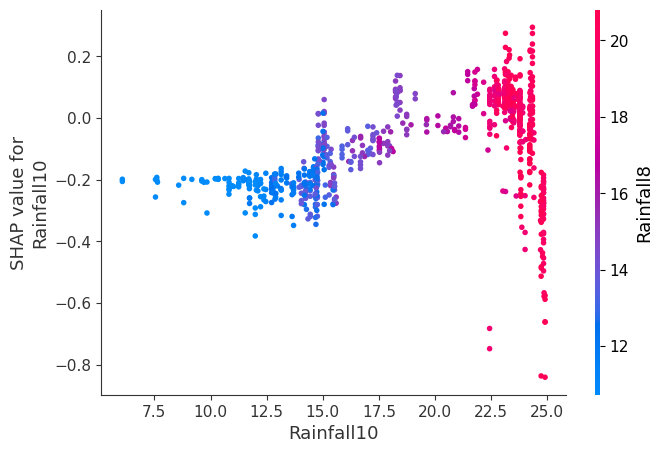

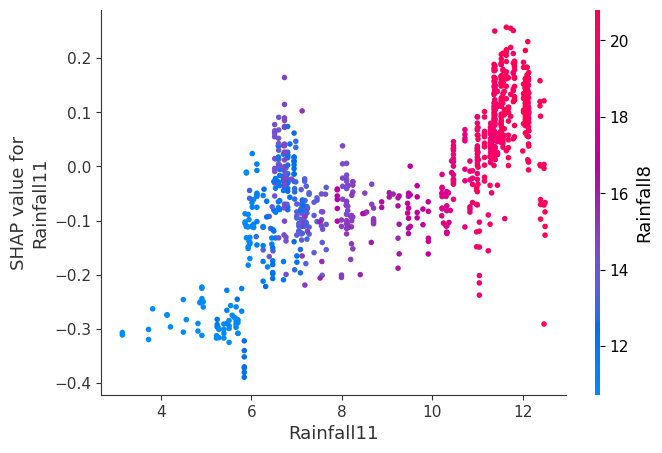

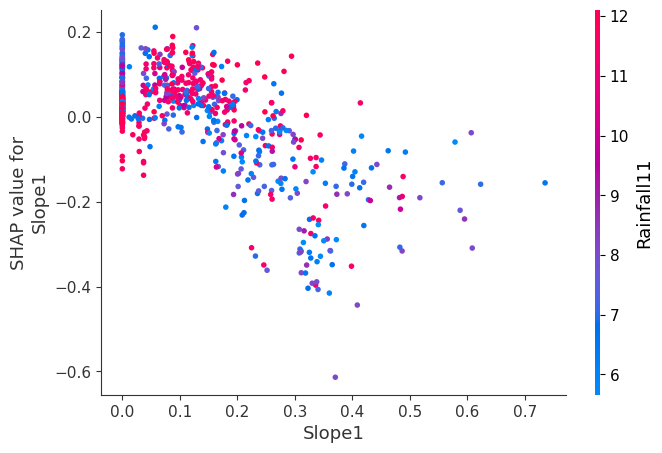

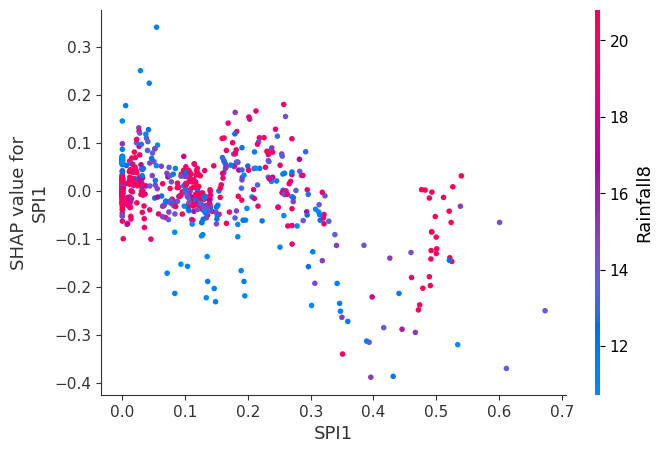

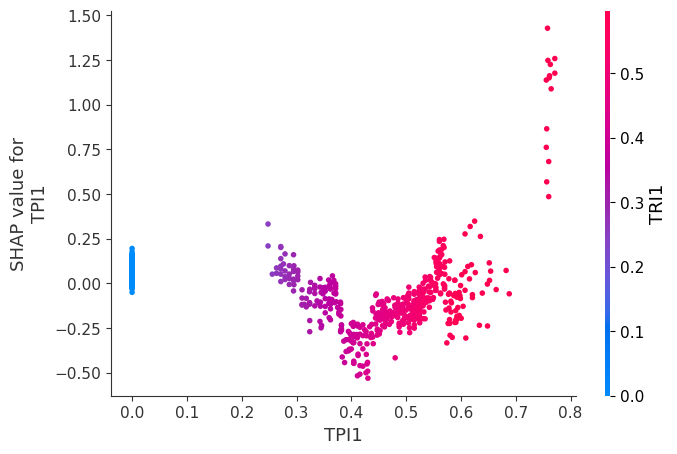

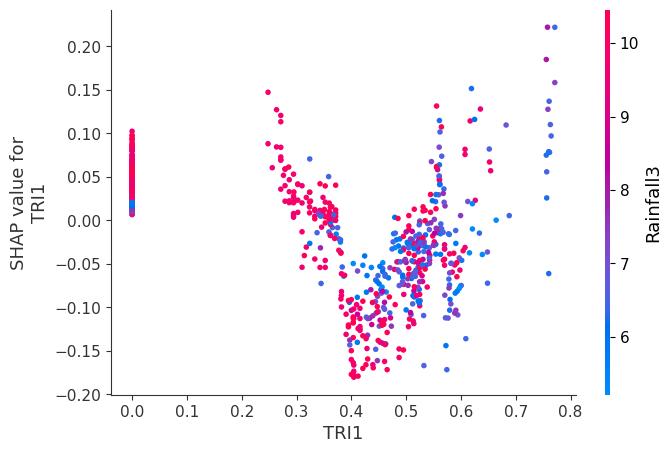

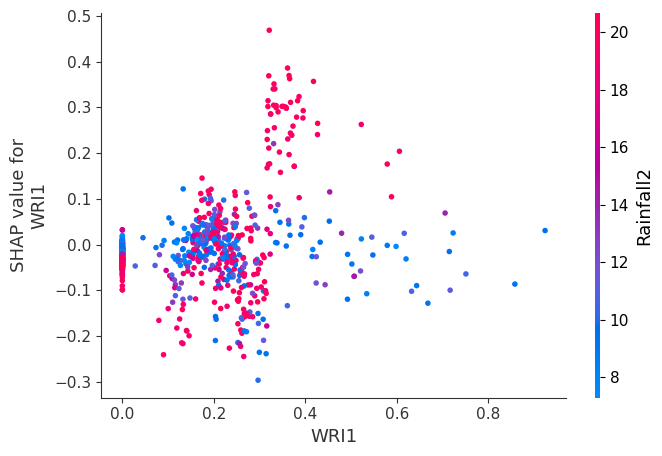

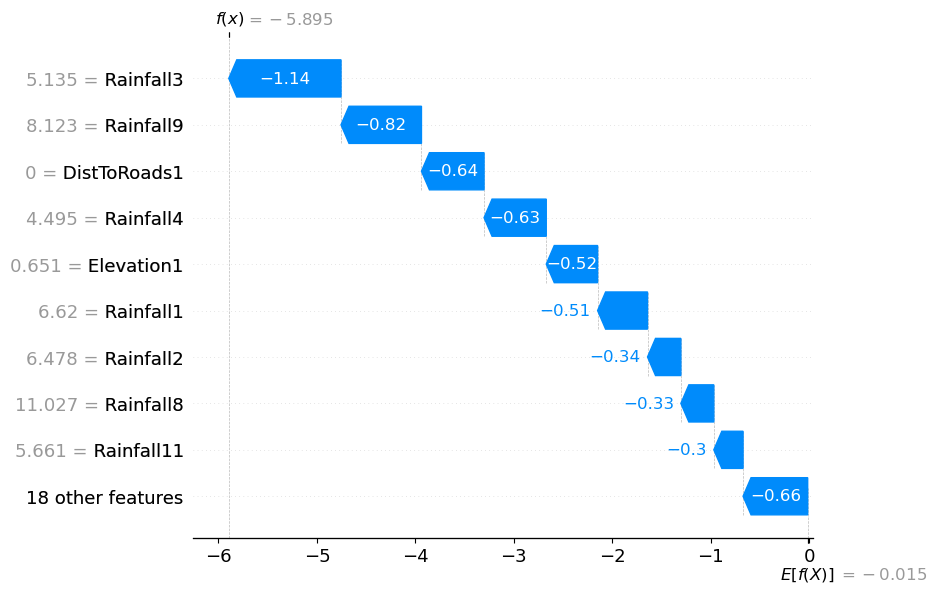

In [55]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Path where all results will be saved
output_dir = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SHAP\XGBoost"
os.makedirs(output_dir, exist_ok=True)

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Save SHAP values (sample-wise)
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv(os.path.join(output_dir, "shap_values_all_samples.csv"), index=False)
print("\n🔹 SHAP values for sample 0:\n", shap_df.iloc[0])

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_global_importance.csv"), index=False)
print("\n📊 Global SHAP importance:\n", shap_importance)

# Plot: Bar chart of global SHAP
plt.figure(figsize=(10, 6))
plt.barh(shap_importance['Feature'], shap_importance['Mean_Absolute_SHAP'])
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance (Mean Absolute SHAP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "bar_plot_mean_absolute_shap.png"), dpi=300)
plt.show()

# Summary Plot (beeswarm)
shap.summary_plot(shap_values, X_test, show=True)
plt.gcf().savefig(os.path.join(output_dir, "summary_plot_beeswarm.png"), dpi=300, bbox_inches='tight')

# Summary Plot (bar)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)
plt.gcf().savefig(os.path.join(output_dir, "summary_plot_bar.png"), dpi=300, bbox_inches='tight')

# Dependence Plots (all features)
for feature in X_test.columns:
    shap.dependence_plot(feature, shap_values, X_test, show=True)
    plt.gcf().savefig(os.path.join(output_dir, f"dependence_plot_{feature}.png"), dpi=300, bbox_inches='tight')
    plt.close()

# Force Plot (interactive for one sample)
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
shap.save_html(os.path.join(output_dir, "force_plot_sample_0.html"), force_plot)

# Waterfall Plot (first sample)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
), show=True)
plt.gcf().savefig(os.path.join(output_dir, "waterfall_plot_sample_0.png"), dpi=300, bbox_inches='tight')
